# Log Transformations - Lab

## Introduction

It's time to practice some logarithmic transformations on the Ames Housing dataset!

## Objectives

You will be able to:

- Determine if a log transformation would be useful for a specific model or set of data
- Apply log transformations to independent and dependent variables in linear regression
- Interpret the coefficients of variables that have been transformed using a log transformation

## Ames Housing Data

Below we load the numeric features from the Ames Housing dataset into a dataframe. We also drop any rows with missing data.

In [1]:
# Run this cell without changes
import pandas as pd
ames = pd.read_csv("ames.csv", index_col=0)
ames = ames.select_dtypes("number")
ames.dropna(inplace=True)
ames

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500


## Identify Good Candidates for Log Transformation

Below we plot each of the potential numeric features against `SalePrice`:

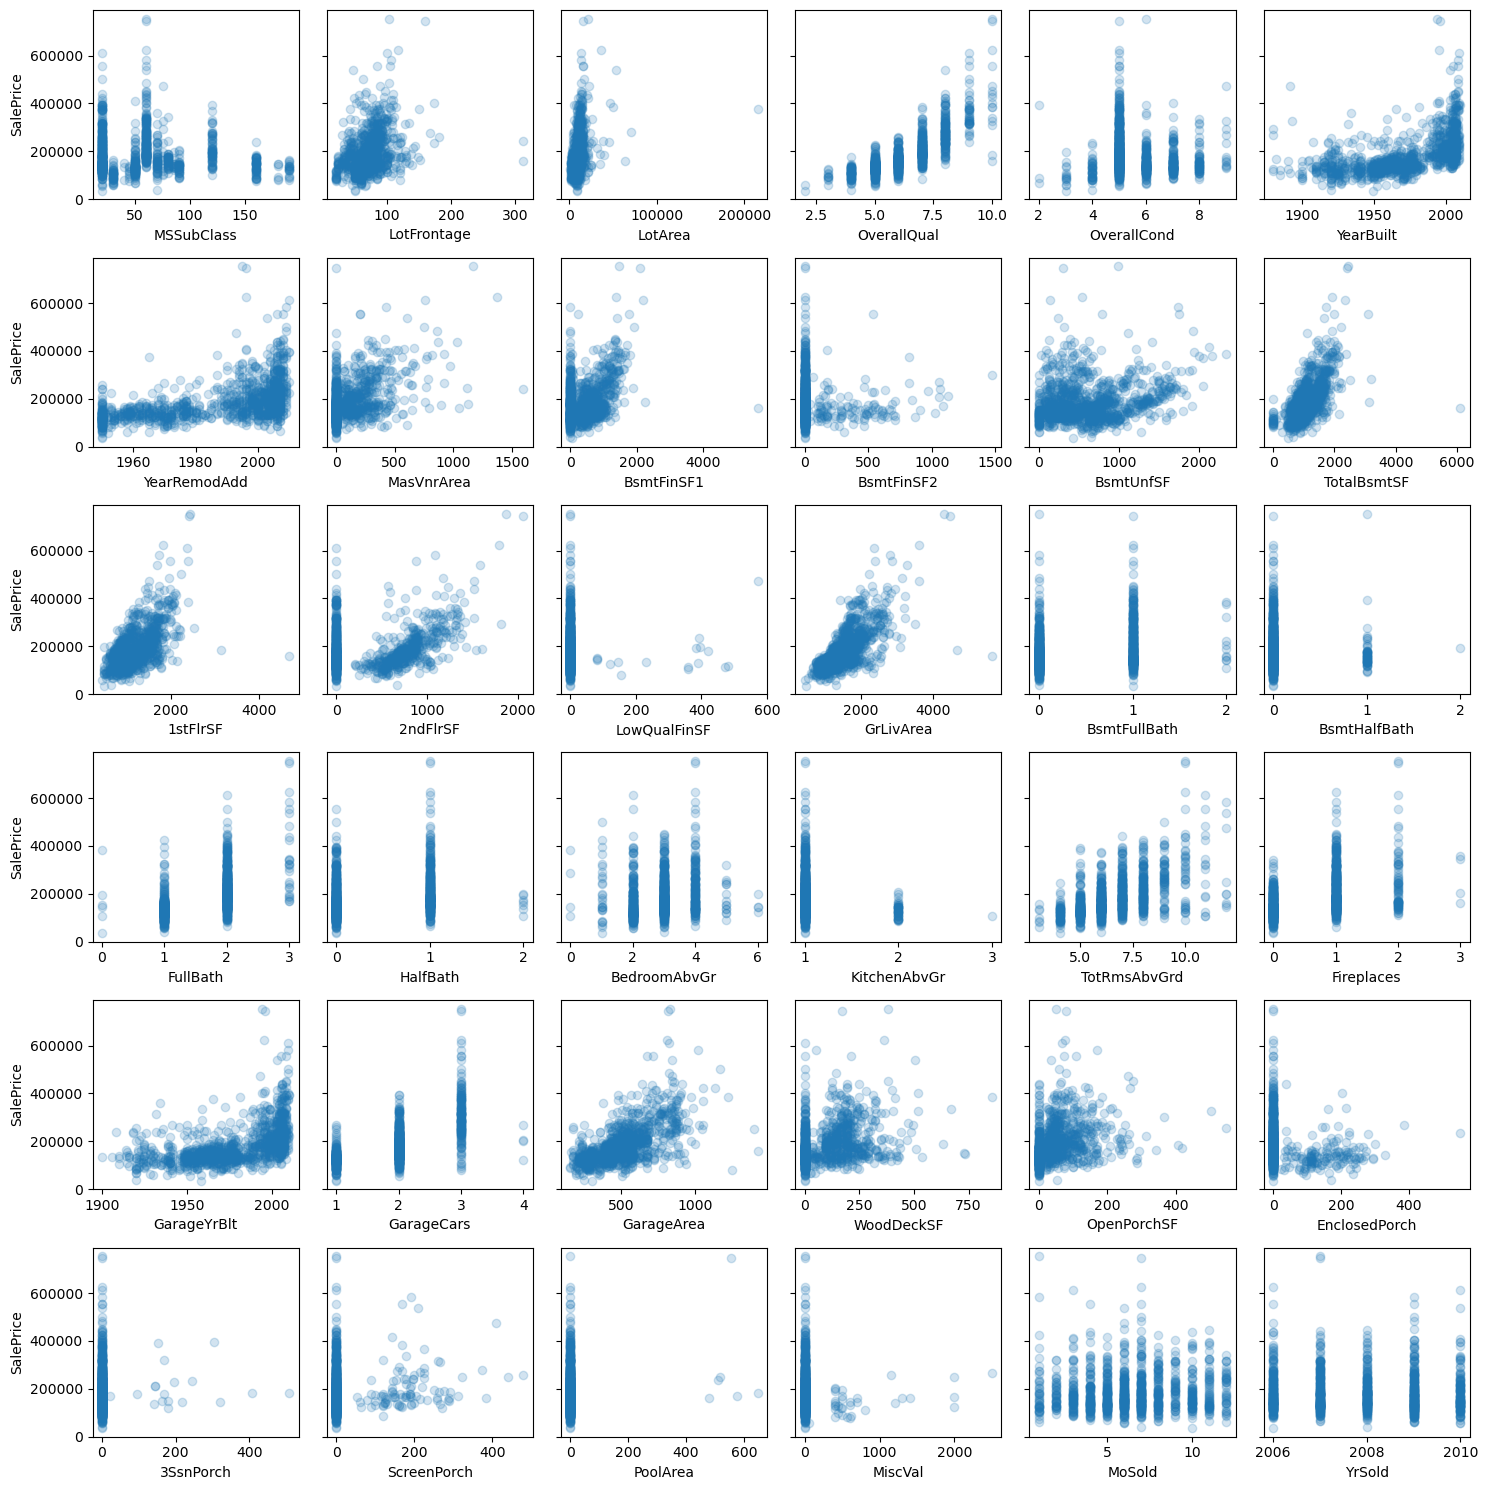

In [2]:
# Run this cell without changes
import matplotlib.pyplot as plt
import numpy as np

y = ames["SalePrice"]
X = ames.drop("SalePrice", axis=1)

fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(15,15), sharey=True)

for i, column in enumerate(X.columns):
    # Locate applicable axes
    row = i // 6
    col = i % 6
    ax = axes[row][col]
    
    # Plot feature vs. y and label axes
    ax.scatter(X[column], y, alpha=0.2)
    ax.set_xlabel(column)
    if col == 0:
        ax.set_ylabel("SalePrice")

fig.tight_layout()

Let's say we want to build a model with **at least one log-transformed feature** as well as a **log-transformed target**

Do you see any features that look like good candidates for this type of transformation?

For reference, a good candidate for this might look like any of these three graphs:

---

<div align="center"><div style="background-image: url('https://upload.wikimedia.org/wikipedia/commons/thumb/0/00/Population_vs_area.svg/256px-Population_vs_area.svg.png'); height: 200px; width: 256px;"></div><a title="Skbkekas, CC BY-SA 3.0 &lt;http://creativecommons.org/licenses/by-sa/3.0/&gt;, via Wikimedia Commons" href="https://commons.wikimedia.org/wiki/File:Population_vs_area.svg">Skbkekas, CC BY-SA 3.0, via Wikimedia Commons</a></div>

---

<div align="center"><img src="http://sciences.usca.edu/biology/zelmer/305/trans/y.jpg" width="256"/>
<a href="http://sciences.usca.edu/biology/zelmer/305/trans/">Derek Zelmer, UCSA</a></div>

---

![e^x](https://curriculum-content.s3.amazonaws.com/data-science/images/log_graphs.png)

Try to find one feature that resembles each of these shapes.

Because this is real-world messy data, none of them are going to match perfectly, and that's ok!

In [3]:
# Your written answer here
ames['GrLivArea'], ames['GarageArea'], ames['1stFlrSF']

Id
1       1710
2       1262
3       1786
4       1717
5       2198
        ... 
1456    1647
1457    2073
1458    2340
1459    1078
1460    1256
Name: GrLivArea, Length: 1121, dtype: int64

### Plot Log Transformed Versions of Features

For each feature that you identified as a good candidate for log transformation, plot the feature vs. `SalePrice` as well as the log transformed feature vs. log transformed `SalePrice`.

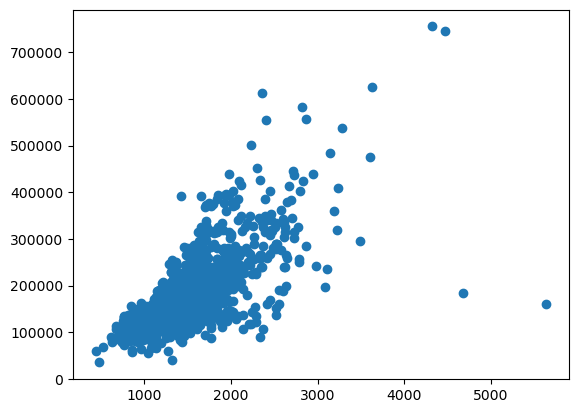

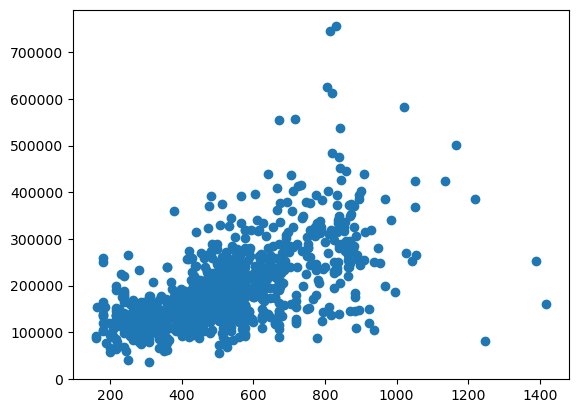

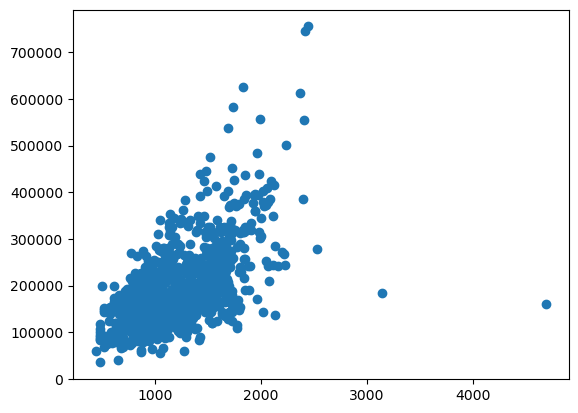

In [9]:
# Your code here
X = [ames['GrLivArea'], ames['GarageArea'], ames['1stFlrSF']]
y = ames['SalePrice']

for x in X:
    plt.scatter(x, y)
    plt.show()
    

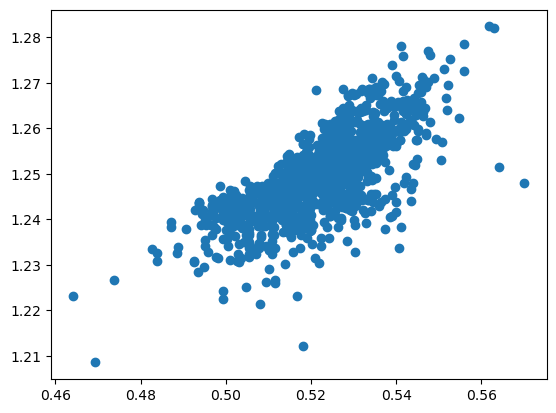

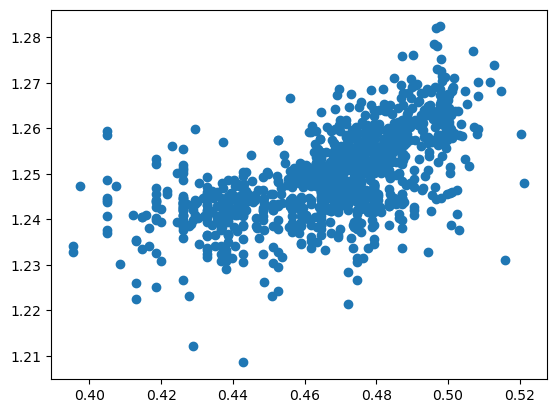

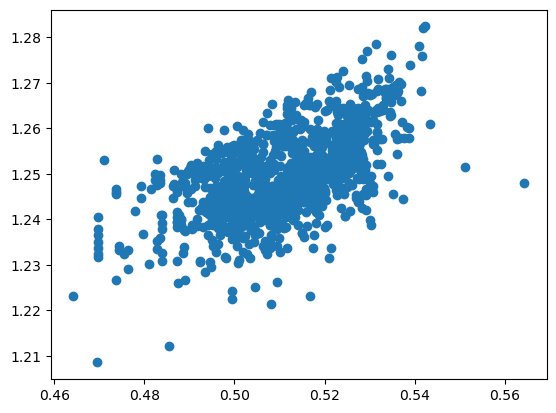

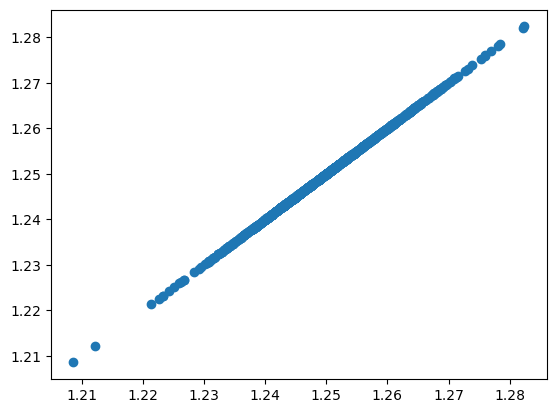

In [29]:
# log transformations
# Convert to numeric
for col in ['GrLivArea', 'GarageArea', '1stFlrSF', 'SalePrice']:
    ames[col] = pd.to_numeric(ames[col], errors='coerce')

cols_to_transform = ['GrLivArea', 'GarageArea', '1stFlrSF', 'SalePrice']
ames[cols_to_transform] = ames[cols_to_transform].apply(np.log1p)


for col in cols_to_transform:
    plt.scatter(ames[col], ames['SalePrice'])
    plt.show()

Do the transformed relationships look more linear? If so, they should be included in the model.

## Build a Model with Log-Transformed Features and Target

### Data Preparation

Choose up to 3 of the features you investigated, and set up an X dataframe containing the log-transformed versions of these features as well as a y series containing the log-transformed version of the target.

---

<details>
    <summary style="cursor: pointer"><b>Hint (click to reveal)</b></summary>

If you are planning log transform a feature measured in _years_ (e.g. `YearRemodAdd`) consider shifting the data first. For example, you might subtract 1900 or 1910 from the year, so that a 1% increase in year is closer to meaning 1 year rather than 20 years.

</details>

In [41]:
# Your code here - prepare data for modeling
y_log = ames['SalePrice']
X_log = ames[['GrLivArea', 'GarageArea', '1stFlrSF']]



In [38]:
for x in X_log:
    print(ames[x])
    print(ames[x].dtypes)

      GrLivArea  GarageArea  1stFlrSF
Id                                   
1      0.528780    0.476610  0.498980
2      0.516343    0.467000  0.516343
3      0.530486    0.482080  0.502341
4      0.528941    0.484879  0.504343
5      0.538391    0.497863  0.512155
...         ...         ...       ...
1456   0.527293    0.467000  0.503961
1457   0.536200    0.471641  0.536200
1458   0.540702    0.429535  0.513754
1459   0.509506    0.426147  0.509506
1460   0.516140    0.435697  0.516140

[1121 rows x 3 columns]
GrLivArea     float64
GarageArea    float64
1stFlrSF      float64
dtype: object


In [33]:
y_log

Id
1       1.254287
2       1.251033
3       1.255899
4       1.244811
5       1.258475
          ...   
1456    1.250169
1457    1.254454
1458    1.259931
1459    1.245176
1460    1.246075
Name: SalePrice, Length: 1121, dtype: float64

### Modeling

Now build a StatsModels OLS model with a log-transformed target as well as log-transformed features.

In [43]:
# Your code here - build a model
import statsmodels.api as sm

model = sm.OLS(y_log, sm.add_constant(X_log))
results = model.fit()

### Model Evaluation and Interpretation

How did the model perform? How might we interpret its coefficients? Create as many cells as needed.

In [44]:
# Your code here - evaluate the model
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.650
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     691.3
Date:                Wed, 17 Sep 2025   Prob (F-statistic):          5.49e-254
Time:                        15:54:42   Log-Likelihood:                 4230.1
No. Observations:                1121   AIC:                            -8452.
Df Residuals:                    1117   BIC:                            -8432.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9438      0.007    130.236      0.000       0.930       0.958
GrLivArea      0.3376      0.015     22.202      0.000       0.308       0.367
GarageArea     0.1193      0.009     13.730      0.000       0.102       0.136
1stFlrSF       0.1446      0.015      9.789      0.000       0.116       0.174
==============================================================================
Omnibus:                      249.770   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              660.720
Skew:                          -1.153   Prob(JB):                    3.36e-144
Kurtosis:                       5.971   Cond. No.                         141.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

- Our model is statistically significant.
- All coefficients are statistically significant.
- For each increase of 1% in above-grade living area, we see an associated increase of about 0.7% in sale price.


## Summary

Now you have practiced modeling with log transformations! This is a subtle, messy process, so don't be discouraged if this was a tricky lab.